# Experiment 4: Binary Classification using Linear and Kernel-Based Models

### Objective
To classify emails as spam or ham using Logistic Regression and Support Vector Machine (SVM) classifiers and to analyze the effect of hyperparameter tuning on classification performance.


# Dataset Used

- **Dataset Name:** Spambase Dataset
- **Number of Records:** 4,601
- **Target Variable:** spam (1 = Spam, 0 = Ham)


## Question 1 : Load the Dataset

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("spambase.csv")
print("Successfully loaded dataset")
print("Dataset Shape:", df.shape)


Successfully loaded dataset
Dataset Shape: (4601, 58)


## Question 2 : Explore the Dataset

In [2]:
import pandas as pd

print("First 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nNull Values per Column:")
print(df.isnull().sum())
print("\nTotal Null Values:", df.isnull().sum().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nClass Distribution:")
print(df['spam'].value_counts())

First 5 rows:
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_;  char_freq_(  \
0             0.00            0.00  ...         0.00     

## Question 3 : Data Preprocessing

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = df.drop_duplicates()
df = df.dropna()

X = df.drop(columns=['spam'])
y = df['spam']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Preprocessed Features Shape:", X_scaled.shape)
print("Target Variable Shape:", y.shape)
print("Total Null Values after Preprocessing:", X_scaled.isnull().sum().sum())

Preprocessed Features Shape: (4210, 57)
Target Variable Shape: (4210,)
Total Null Values after Preprocessing: 0


## Question 4 : Exploratory Data Analysis (EDA)

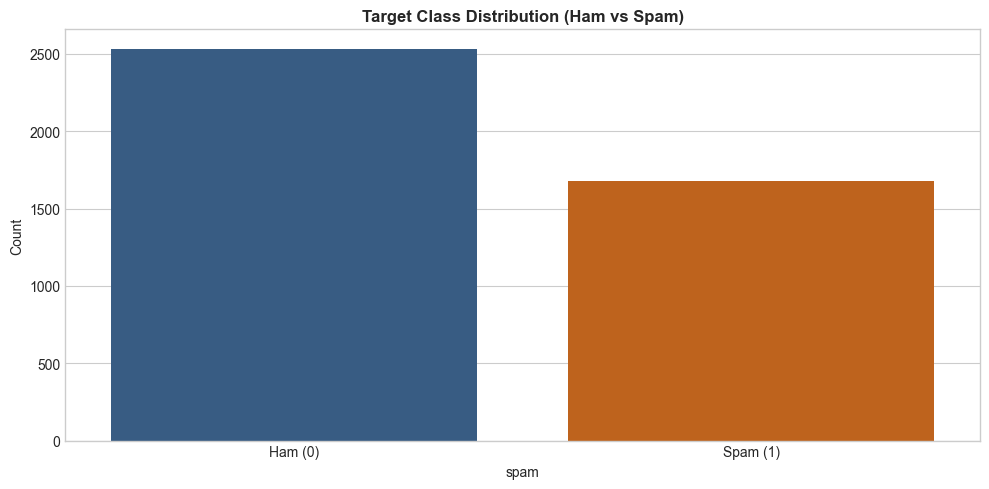

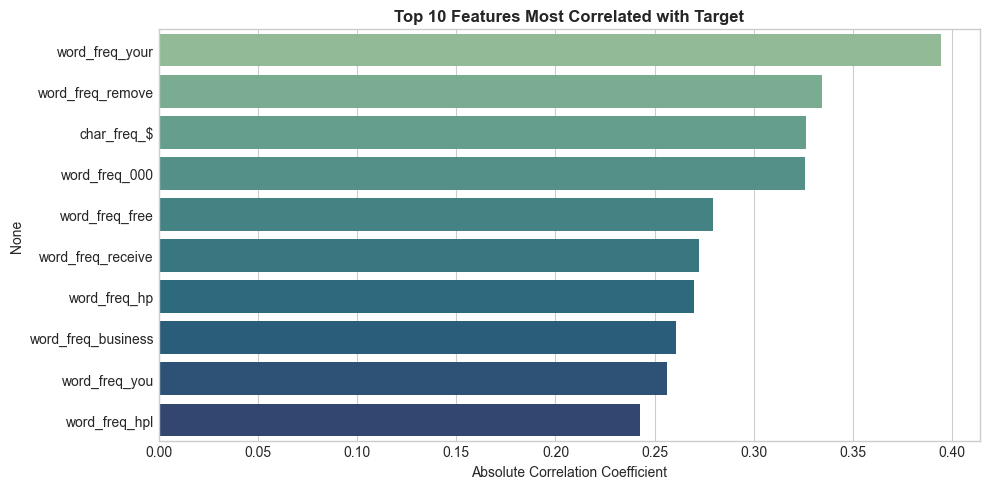

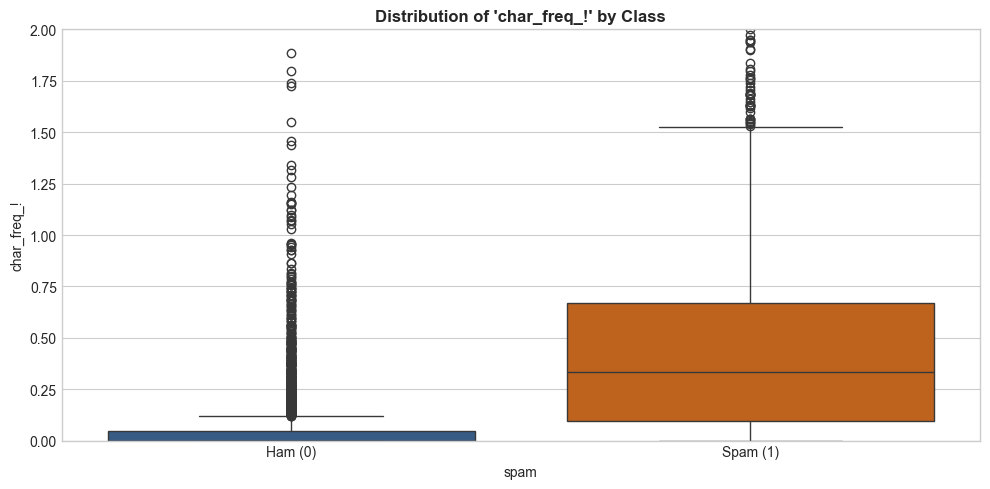

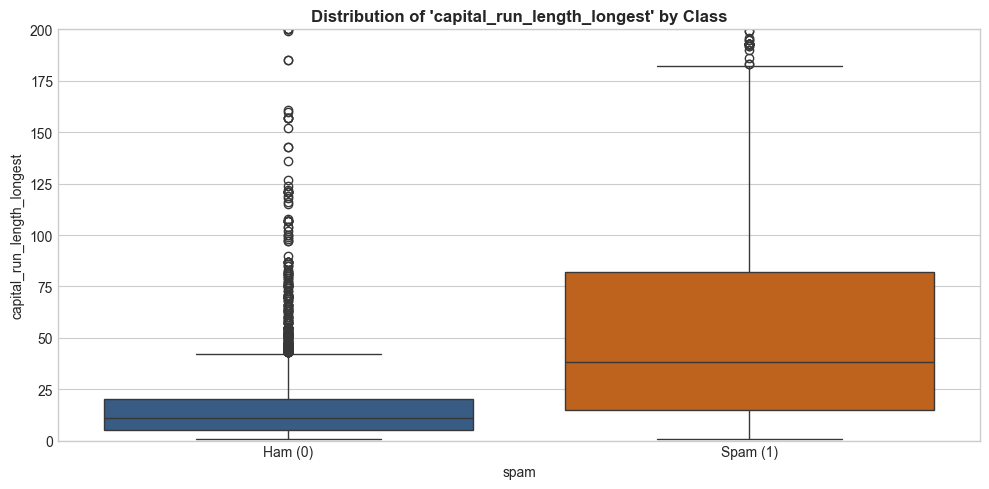

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(10, 5))
sns.countplot(x=y, hue=y, palette=['#2b5c8f', '#d95f02'], legend=False)
plt.title('Target Class Distribution (Ham vs Spam)', fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
num_df = df.select_dtypes(include=[np.number])
top_corr = num_df.corr()['spam'].abs().sort_values(ascending=False).head(11)
sns.barplot(x=top_corr.values[1:], y=top_corr.index[1:], hue=top_corr.index[1:], palette='crest', legend=False)
plt.title('Top 10 Features Most Correlated with Target', fontsize=12, fontweight='bold')
plt.xlabel('Absolute Correlation Coefficient')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=y, y=df['char_freq_!'], hue=y, palette=['#2b5c8f', '#d95f02'], legend=False)
plt.title("Distribution of 'char_freq_!' by Class", fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.ylim(0, 2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=y, y=df['capital_run_length_longest'], hue=y, palette=['#2b5c8f', '#d95f02'], legend=False)
plt.title("Distribution of 'capital_run_length_longest' by Class", fontsize=12, fontweight='bold')
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'])
plt.ylim(0, 200)
plt.tight_layout()
plt.show()

## Question 5 : Split the Dataset into Training and Testing Sets

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Class Distribution:")
print(y_train.value_counts())
print("Testing Class Distribution:")
print(y_test.value_counts())

Training Features Shape: (3368, 57)
Testing Features Shape: (842, 57)
Training Class Distribution:
spam
0    2025
1    1343
Name: count, dtype: int64
Testing Class Distribution:
spam
0    506
1    336
Name: count, dtype: int64


## Question 6 : Train Baseline Logistic Regression

In [6]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

start_time = time.time()
lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

y_pred_lr = lr_baseline.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print(f"Accuracy         : {lr_acc:.4f}")
print(f"Precision        : {lr_prec:.4f}")
print(f"Recall           : {lr_rec:.4f}")
print(f"F1 Score         : {lr_f1:.4f}")
print(f"Training Time (s): {lr_train_time:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))

Accuracy         : 0.9347
Precision        : 0.9297
Recall           : 0.9048
F1 Score         : 0.9170
Training Time (s): 0.0519

Confusion Matrix:
[[483  23]
 [ 32 304]]

Classification Report:
              precision    recall  f1-score   support

         Ham       0.94      0.95      0.95       506
        Spam       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842



## Question 7 : Tune Logistic Regression Hyperparameters

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_param_grid = [
    {'penalty': ['l1', 'l2'], 'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear']}
]

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

lr_grid_search.fit(X_train, y_train)

lr_best_params = lr_grid_search.best_params_
lr_best_cv_acc = lr_grid_search.best_score_

print("Best Parameters:", lr_best_params)
print(f"Best CV Accuracy: {lr_best_cv_acc:.4f}")

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy: 0.9240


## Question 8 : Train SVM with Different Kernels

In [8]:
import time
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []

for k in kernels:
    start_time = time.time()
    svm_model = SVC(kernel=k, random_state=42)
    svm_model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred_k = svm_model.predict(X_test)
    acc_k = accuracy_score(y_test, y_pred_k)
    f1_k = f1_score(y_test, y_pred_k)
    
    kernel_results.append({
        'Kernel': k.capitalize() if k != 'rbf' else 'RBF',
        'Accuracy': round(acc_k, 4),
        'F1 Score': round(f1_k, 4),
        'Training Time (s)': round(train_time, 4)
    })

df_kernel_perf = pd.DataFrame(kernel_results)
print(df_kernel_perf.to_string(index=False))

 Kernel  Accuracy  F1 Score  Training Time (s)
 Linear    0.9311    0.9132             0.2858
   Poly    0.7660    0.5988             0.2764
    RBF    0.9299    0.9102             0.1795
Sigmoid    0.8884    0.8563             0.1564


## Question 9 : Tune SVM Hyperparameters

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC

svm_param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    {'kernel': ['poly'], 'C': [0.1, 1], 'degree': [2, 3], 'gamma': ['scale']},
    {'kernel': ['sigmoid'], 'C': [0.1, 1], 'gamma': ['scale']}
]

svm_random_search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=svm_param_grid,
    n_iter=6,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)

svm_random_search.fit(X_train, y_train)

svm_best_params = svm_random_search.best_params_
svm_best_cv_acc = svm_random_search.best_score_

print("Best Parameters:", svm_best_params)
print(f"Best CV Accuracy: {svm_best_cv_acc:.4f}")

Best Parameters: {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}
Best CV Accuracy: 0.9246


## Question 10 : Perform 5-Fold Cross-Validation (K = 5)

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_lr = LogisticRegression(**lr_best_params, random_state=42, max_iter=1000)
lr_cv_scores = cross_val_score(tuned_lr, X_scaled, y, cv=cv_strategy, scoring='accuracy', n_jobs=1)

tuned_svm = SVC(**svm_best_params, random_state=42)
svm_cv_scores = cross_val_score(tuned_svm, X_scaled, y, cv=cv_strategy, scoring='accuracy', n_jobs=1)

cv_data = {
    'Fold': ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Average'],
    'Logistic Regression': [round(s, 4) for s in lr_cv_scores] + [round(np.mean(lr_cv_scores), 4)],
    'SVM': [round(s, 4) for s in svm_cv_scores] + [round(np.mean(svm_cv_scores), 4)]
}

df_cv_results = pd.DataFrame(cv_data)
print(df_cv_results.to_string(index=False))

   Fold  Logistic Regression    SVM
 Fold 1               0.9276 0.9276
 Fold 2               0.9418 0.9454
 Fold 3               0.9264 0.9311
 Fold 4               0.9145 0.9157
 Fold 5               0.9181 0.9228
Average               0.9257 0.9285


## Question 11 : Hyperparameter Tuning Results & Comparative Analysis

In [11]:
import time
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_lr.fit(X_train, y_train)
lr_final_pred = tuned_lr.predict(X_test)

start_time = time.time()
tuned_svm.fit(X_train, y_train)
svm_train_time = time.time() - start_time
svm_final_pred = tuned_svm.predict(X_test)

lr_perf_summary = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Training Time (s)'],
    'Value': [
        round(accuracy_score(y_test, lr_final_pred), 4),
        round(precision_score(y_test, lr_final_pred), 4),
        round(recall_score(y_test, lr_final_pred), 4),
        round(f1_score(y_test, lr_final_pred), 4),
        round(lr_train_time, 4)
    ]
}

df_lr_perf = pd.DataFrame(lr_perf_summary)

tuning_summary = {
    'Model': ['Logistic Regression', 'SVM'],
    'Search Method': ['Grid Search', 'Randomized Search'],
    'Best Parameters': [str(lr_best_params), str(svm_best_params)],
    'Best CV Accuracy': [round(lr_best_cv_acc, 4), round(svm_best_cv_acc, 4)]
}

df_tuning_summary = pd.DataFrame(tuning_summary)

print(df_tuning_summary.to_string(index=False))

print(df_lr_perf.to_string(index=False))

print(df_kernel_perf.to_string(index=False))

print(df_cv_results.to_string(index=False))

              Model     Search Method                                  Best Parameters  Best CV Accuracy
Logistic Regression       Grid Search {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}            0.9240
                SVM Randomized Search      {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}            0.9246
           Metric  Value
         Accuracy 0.9371
        Precision 0.9301
           Recall 0.9107
         F1 Score 0.9203
Training Time (s) 0.0519
 Kernel  Accuracy  F1 Score  Training Time (s)
 Linear    0.9311    0.9132             0.2858
   Poly    0.7660    0.5988             0.2764
    RBF    0.9299    0.9102             0.1795
Sigmoid    0.8884    0.8563             0.1564
   Fold  Logistic Regression    SVM
 Fold 1               0.9276 0.9276
 Fold 2               0.9418 0.9454
 Fold 3               0.9264 0.9311
 Fold 4               0.9145 0.9157
 Fold 5               0.9181 0.9228
Average               0.9257 0.9285
